<a href="https://colab.research.google.com/github/isismeira/natural_language_processing/blob/main/naive_bayes_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de sentimentos em tweets sobre Covid-19: um comparativo entre Regressão Logística e Naive-Bayes

## Importação de biliotecas

In [94]:
import pandas as pd
import spacy
import nltk
import string
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from spacy.lang.en.stop_words import STOP_WORDS
from spacy.lang.en import English

In [95]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.base import TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV

## Pré-processamento de dados

In [96]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [97]:
cd drive/MyDrive/

[Errno 2] No such file or directory: 'drive/MyDrive/'
/content/drive/MyDrive


In [98]:
train_df = pd.read_csv('corona_tweets_nlp/Corona_NLP_train.csv', encoding='ISO-8859-1', parse_dates=['TweetAt'])
test_df = pd.read_csv('corona_tweets_nlp/Corona_NLP_test.csv', encoding='ISO-8859-1', parse_dates=['TweetAt'])

/tmp/ipython-input-98-1783957567.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  train_df = pd.read_csv('corona_tweets_nlp/Corona_NLP_train.csv', encoding='ISO-8859-1', parse_dates=['TweetAt'])


As primeiras instâncias do dataframe de treino, observa-se que somente a coluna Original_Tweet e Sentiment são relevantes para treinar o modelo

In [99]:
train_df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,2020-03-16,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,2020-03-16,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,2020-03-16,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,2020-03-16,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,2020-03-16,"Me, ready to go at supermarket during the #COV...",Extremely Negative


In [100]:
train_df.loc[10]['OriginalTweet']

"All month there hasn't been crowding in the supermarkets or restaurants, however reducing all the hours and closing the malls means everyone is now using the same entrance and dependent on a single supermarket. #manila #lockdown #covid2019 #Philippines https://t.co/HxWs9LAnF9"

Primeiras instâncias do dataframe de teste

In [101]:
test_df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,1,44953,NYC,02-03-2020,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,2,44954,"Seattle, WA",02-03-2020,When I couldn't find hand sanitizer at Fred Me...,Positive
2,3,44955,NaN,02-03-2020,Find out how you can protect yourself and love...,Extremely Positive
3,4,44956,Chicagoland,02-03-2020,#Panic buying hits #NewYork City as anxious sh...,Negative
4,5,44957,"Melbourne, Victoria",03-03-2020,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral


In [102]:
train_df.shape, test_df.shape

((41157, 6), (3798, 6))

Juntando o conjunto de treinamento e de teste para ter um vocabulário único para realizar o bag of words e fazer pré processamento para todos dados

In [103]:
# Criando mais uma coluna para indicar se a instância faz parte do conjunto de teste ou não
train_df['is_test'] = 0
test_df['is_test'] = 1

# Juntando os dois dataframes
comp_df = pd.concat([train_df, test_df])
comp_df.reset_index(drop=True, inplace=True)

In [104]:
train_df.loc[4]['OriginalTweet']

"Me, ready to go at supermarket during the #COVID19 outbreak.\r\r\n\r\r\nNot because I'm paranoid, but because my food stock is litteraly empty. The #coronavirus is a serious thing, but please, don't panic. It causes shortage...\r\r\n\r\r\n#CoronavirusFrance #restezchezvous #StayAtHome #confinement https://t.co/usmuaLq72n"

In [105]:
comp_df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,is_test
0,3799,48751,London,2020-03-16 00:00:00,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral,0
1,3800,48752,UK,2020-03-16 00:00:00,advice Talk to your neighbours family to excha...,Positive,0
2,3801,48753,Vagabonds,2020-03-16 00:00:00,Coronavirus Australia: Woolworths to give elde...,Positive,0
3,3802,48754,NaN,2020-03-16 00:00:00,My food stock is not the only one which is emp...,Positive,0
4,3803,48755,NaN,2020-03-16 00:00:00,"Me, ready to go at supermarket during the #COV...",Extremely Negative,0


In [106]:
comp_df.shape

(44955, 7)

Para focar apenas o texto, preservar somente as colunas contendo o tweet, a classe atribuída a ele e se é do conjunto de testes ou não

In [107]:
comp_df = comp_df[['OriginalTweet', 'Sentiment', 'is_test']]
comp_df.columns= ['tweet', 'label', 'is_test']

In [108]:
comp_df.head()

,tweet,label,is_test
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral,0
1,advice Talk to your neighbours family to excha...,Positive,0
2,Coronavirus Australia: Woolworths to give elde...,Positive,0
3,My food stock is not the only one which is emp...,Positive,0
4,"Me, ready to go at supermarket during the #COV...",Extremely Negative,0


Trataento para remover tags '@', '#', URLs, espaços extra e transformando todas as palavras para lowercase

In [109]:
# Removendo tags '@'
comp_df.tweet = comp_df.tweet.str.replace(r'@\w+', '', regex=True)

# Removendo URL
comp_df.tweet = comp_df.tweet.str.replace(r"http\S+|https\S+", "", regex=True)

# Removendo tags '#'
comp_df.tweet = comp_df.tweet.str.replace(r'#+', "", regex=True)

#Removendo espaço extra
comp_df.tweet = comp_df.tweet.str.replace(r'( +)', " ", regex=True)
comp_df.tweet = comp_df.tweet.str.strip()

# Mudando para lowercase
comp_df.tweet = comp_df.tweet.str.lower()

In [110]:
train_df.loc[0]['OriginalTweet']

'@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/iFz9FAn2Pa and https://t.co/xX6ghGFzCC and https://t.co/I2NlzdxNo8'

In [111]:
comp_df.head()

,tweet,label,is_test
0,and and,Neutral,0
1,advice talk to your neighbours family to excha...,Positive,0
2,coronavirus australia: woolworths to give elde...,Positive,0
3,my food stock is not the only one which is emp...,Positive,0
4,"me, ready to go at supermarket during the covi...",Extremely Negative,0


Novo dataframe após alterações

In [112]:
comp_df.loc[4]['tweet']

"me, ready to go at supermarket during the covid19 outbreak.\r\r\n\r\r\nnot because i'm paranoid, but because my food stock is litteraly empty. the coronavirus is a serious thing, but please, don't panic. it causes shortage...\r\r\n\r\r\ncoronavirusfrance restezchezvous stayathome confinement"

Agora cada rótulo ao invés de ser um texto vai virar um número inteiro

In [113]:
comp_df['label'] = comp_df.label.replace('Extremely Negative', 1)
comp_df['label'] = comp_df.label.replace('Negative', 1)
comp_df['label'] = comp_df.label.replace('Neutral', 2)
comp_df['label'] = comp_df.label.replace('Positive', 3)
comp_df['label'] = comp_df.label.replace('Extremely Positive', 3)

/tmp/ipython-input-113-1014426561.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  comp_df['label'] = comp_df.label.replace('Extremely Positive', 3)


In [114]:
comp_df.label.value_counts()

,count
label,
3,19592
1,17031
2,8332


## Tokenização

In [115]:
from spacy.lang.en import English
nlp = English()

In [116]:
# Lista de sinais de pontuação
punctuations = string.punctuation

# Criando lista de stopwords
nlp = spacy.load('en_core_web_sm')
stop_words = spacy.lang.en.stop_words.STOP_WORDS

# Carregando tokenizador, tagger, parser, NER e word vectors
parser = English()

def spacy_tokenizer(sentence):
    # Criando o objeto token
    mytokens = nlp(sentence)

    # Lematização dos tokenizadores e passando os tokens para lowercase
    mytokens = [ word.lemma_.lower() for word in mytokens ] # Removed strip() here

    # removendo stop words e pontuações
    mytokens = [ word for word in mytokens if word not in stop_words and word not in punctuations and word.strip() != ''] # Added strip() check and punctuation removal

    return mytokens

Chamando o tokenizador para o tweet

Tokens em formato de lista

In [117]:
comp_df['corpus'] = [spacy_tokenizer(tweet) for tweet in comp_df.tweet]
comp_df.head()

,tweet,label,is_test,corpus
0,and and,2,0,[]
1,advice talk to your neighbours family to excha...,3,0,"[advice, talk, neighbour, family, exchange, ph..."
2,coronavirus australia: woolworths to give elde...,3,0,"[coronavirus, australia, woolworth, elderly, d..."
3,my food stock is not the only one which is emp...,3,0,"[food, stock, ..., panic, food, need, stay, ca..."
4,"me, ready to go at supermarket during the covi...",1,0,"[ready, supermarket, covid19, outbreak, parano..."


In [118]:
comp_df.loc[4]['corpus']

['ready',
 'supermarket',
 'covid19',
 'outbreak',
 'paranoid',
 'food',
 'stock',
 'litteraly',
 'coronavirus',
 'thing',
 'panic',
 'cause',
 'shortage',
 '...',
 'coronavirusfrance',
 'restezchezvous',
 'stayathome',
 'confinement']

Tokens em formato textual

In [119]:
comp_df.corpus = comp_df.apply(lambda x: " ".join(x['corpus']), axis=1)
comp_df.head()

,tweet,label,is_test,corpus
0,and and,2,0,
1,advice talk to your neighbours family to excha...,3,0,advice talk neighbour family exchange phone nu...
2,coronavirus australia: woolworths to give elde...,3,0,coronavirus australia woolworth elderly disabl...
3,my food stock is not the only one which is emp...,3,0,food stock ... panic food need stay calm stay ...
4,"me, ready to go at supermarket during the covi...",1,0,ready supermarket covid19 outbreak paranoid fo...


## Convertendo texto para bag-of-words (BOW)

Separando os atributos e as classes para o conjunto de treino e teste

In [120]:
x_train = comp_df.corpus[comp_df.is_test==0]
y_train = comp_df.label[comp_df.is_test==0]
x_test = comp_df.corpus[comp_df.is_test==1]
y_test= comp_df.label[comp_df.is_test==1]

Convertendo em BOW com valoização de frequência

In [121]:
# Criando o bag-of-words
freq_vector = CountVectorizer(min_df=5, ngram_range=(1,2), stop_words='english').fit(comp_df.corpus) # só entra se teve no mínimo 5 ocorrências

# Contagem
x_train = freq_vector.transform(comp_df.corpus[comp_df.is_test==0])
x_test = freq_vector.transform(comp_df.corpus[comp_df.is_test==1])

In [122]:
x_train.shape

(41157, 24267)

In [123]:
x_test.shape

(3798, 24267)

24267 palavras únicas

## Modelo de Regressão Logística

In [124]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(max_iter=500)

classifier.fit(x_train, y_train)

LogisticRegression(max_iter=500)

In [125]:
from sklearn.metrics import precision_recall_fscore_support
y_pred_train = classifier.predict(x_train)
precision_recall_fscore_support(y_train, y_pred_train, average='macro')

(0.9674816967455859, 0.9661443502240897, 0.966807473608967, None)

In [126]:
y_pred = classifier.predict(x_test)
precision_recall_fscore_support(y_test, y_pred, average='macro')

(0.7397023405492881, 0.7439069550594941, 0.7415888466935897, None)

In [127]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

In [128]:
def plot_cm(conf_matrix):
  sns.set(font_scale=1.4, color_codes=True, palette="deep")
  sns.heatmap(cm,annot=True,annot_kws={"size":16},fmt="d",cmap="Blues")
  plt.title("Confusion Matrix")
  plt.xlabel("Predicted Value")
  plt.ylabel("Actual Value")

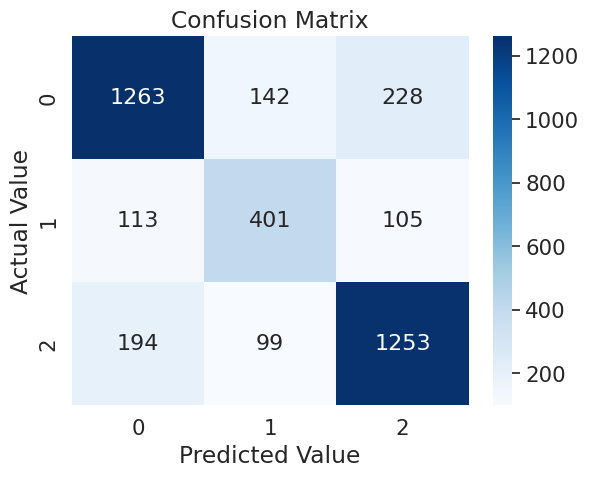

In [129]:
plot_cm(cm)

In [130]:
cross_val_score(LogisticRegression(random_state=42), x_train, y_train, cv=10, verbose=1, n_jobs=-1).mean()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   28.1s finished


np.float64(0.7718740546036154)

Agora, tentar encontrar os melhores hiperparâmetros com Grid Search

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver

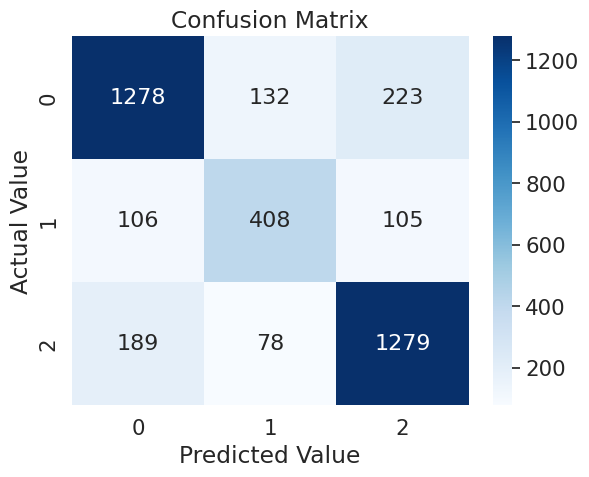

In [131]:
params = {
    'C':[0.001, 0.01, 0.1, 1, 10, 100],
    'penalty':['l1', 'l2']
}

lr_grid = GridSearchCV(LogisticRegression(random_state=42), params, cv=5, verbose=2, n_jobs=-1)
lr_grid.fit(x_train, y_train)

y_predict =lr_grid.predict(x_test)
cm = confusion_matrix(y_test, y_predict)
plot_cm(cm)

In [132]:
precision_recall_fscore_support(y_test, y_predict, average='macro')

(0.7561824700089496, 0.7563441897456787, 0.7560688165342224, None)

In [133]:
y_pred = classifier.predict(x_train)
precision_recall_fscore_support(y_train, y_pred, average='macro')

(0.9674816967455859, 0.9661443502240897, 0.966807473608967, None)

## Modelo com Naive-Bayes

In [134]:
from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()
mnb.fit(x_train.toarray()[:10000], y_train[:10000]) # passando menos exemplos

MultinomialNB()

In [135]:
y_pred = mnb.predict(x_test)
precision_recall_fscore_support(y_test, y_pred, average='macro')

(0.6143351800943871, 0.5656017162039978, 0.5741561052043932, None)

In [136]:
y_pred_train = mnb.predict(x_train)
precision_recall_fscore_support(y_train, y_pred_train, average='macro')

(0.6716191051952721, 0.6269320896245204, 0.6361918025681145, None)